Interpolacion Mínimos Cuadrados

Ejercicio 9.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as i_p

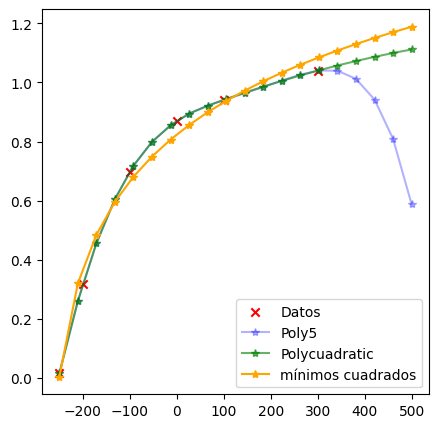

In [43]:
Tc = (-250, -200, -100, 0,100,300)
Cp = (0.0163, 0.318, 0.699, 0.870, 0.941, 1.04)

limites = (-250, 500)



X = np.linspace(limites[0], limites[1], 20)

# Datos
plt.figure(figsize=(5,5))
plt.scatter(x = Tc, y = Cp, marker="x", color= "r", label="Datos")

# Interpolación
coeff = np.polyfit(Tc, Cp, deg=len(Tc)-1)
plt.plot(X, np.polyval(coeff,X), "-*b", alpha=0.3, label= "Poly5")

# Interpolación por partes
poly_inter = i_p.interp1d(Tc, Cp, "quadratic", fill_value="extrapolate")
plt.plot(X, poly_inter(X), "-*g", alpha=0.6, label="Polycuadratic")

# Interpolación por mínimos cuadrados
from scipy.optimize import curve_fit
def modelo_log(x, a, b, c, d, offset):
    return a * np.log(b * (x - c) + offset) + d
offset_inicial = 1000
parametros, cov = curve_fit(modelo_log, Tc, Cp, p0=[1, 10, -251, 1, offset_inicial], bounds=([-np.inf, 0, -np.inf, -np.inf, 0], np.inf))

plt.plot(X, modelo_log(X, *parametros),"-*", color = "orange", label="mínimos cuadrados")

# Mostrar
plt.legend()
plt.show()